# Tips Prediction of New York Yellow Taxi Customers in January 2009 

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

From all the features available, the selected features are:
1. Trip_Pickup_DateTime which is pick up time of the customer.
2. Trip_Dropoff_DateTime which is the drop off time of the customer.
3. Passenger_Count which is the number of passenger.
4. Trip_Distance which is the distance of the trip.
5. Payment_Type which is the type of payment. Either with cash or credit card.
6. Fare_amt which is the amount that customer paid.
7. Tip_Amt which is the amount of tips given by the passenger.

In [2]:
data_jan_2009 = pl.read_parquet("C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi/yellow_tripdata_2009-01.parquet", 
                                columns=['Trip_Pickup_DateTime','Trip_Dropoff_DateTime','Passenger_Count','Trip_Distance',
                                         'Payment_Type','Fare_Amt','Tip_Amt'])

In [3]:
len(data_jan_2009) # number of row data

14092413

In [4]:
data_jan_2009.head()

Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amt,Tip_Amt
str,str,i64,f64,str,f64,f64
"""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,"""CASH""",8.9,0.0
"""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,"""Credit""",12.1,2.0
"""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,"""Credit""",23.7,4.74
"""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,"""CREDIT""",14.9,3.05
"""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,"""CASH""",3.7,0.0


Notice that the type of data is string for pick up and drop off time. We need to convert the type to data to date time type if we want to use the length of trip as the difference of drop off time and the pick up time. At first the name of coulmns are renamed.

In [5]:
data_jan_2009 = data_jan_2009.rename({
    "Trip_Pickup_DateTime": "trip_pickup_dateTime",
    "Trip_Dropoff_DateTime": "trip_dropoff_dateTime",
    "Passenger_Count": "passenger_count",
    "Trip_Distance": "trip_distance",
    "Payment_Type": "payment_type",
    "Fare_Amt": "fare_amt",
    "Tip_Amt": "tip_amt"
})

## Step 1: Filter data
Remove data that meaningles such as has negative number of passenger, negative trip distance, negative fare and negative tips amount. Besides that, it is assumed that maximum trip is 50 miles.

In [6]:
data_jan_2009 = data_jan_2009.filter(
    (pl.col("passenger_count") >= 0) & (pl.col("trip_distance") >= 0) & (pl.col("trip_distance") <= 50) & 
    (pl.col("fare_amt") >= 0) & (pl.col("tip_amt") >= 0)
)
len(data_jan_2009)

14092413

## Step 2: Tips record only for Customer Who Pays with Credit Card
For that reason, we need to filter data which only include the customer that pays with credit card.

In [7]:
mapping = {
    "Credit": 0,
    "CREDIT": 0,
    "CASH": 1,
    "Cash": 1,
    "No Charge": 2,
    "Dispute": 3
}

data_jan_2009 = data_jan_2009.with_columns(
    pl.col("payment_type").replace(mapping)
)

In [8]:
# Convert column of payment_type from string to integer
data_jan_2009 = data_jan_2009.with_columns(
    pl.col("payment_type").cast(pl.Int64)
)

In [9]:
# Filter data which customer only paid with credit card
data_jan_2009 = data_jan_2009.filter(
    (pl.col("payment_type") == 0) 
)

## Step 3: Remove Data that Length of Service more than 24 Hours
It is assumed that duration of each trip is not more than 24 hours.

In [10]:
# Convert pick up and drop off column from string to date time.
data_jan_2009 = data_jan_2009.with_columns([
    pl.col("trip_pickup_dateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
    pl.col("trip_dropoff_dateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
    pl.col("payment_type").cast(pl.Int64)
])

In [11]:
# Count duration of trip in days
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("trip_dropoff_dateTime") - pl.col("trip_pickup_dateTime")).dt.total_seconds() / 86400)
    .cast(pl.Int64)
    .alias("duration_days")
)

In [12]:
# Only include data that duration is less than 1 day
data_jan_2009 = data_jan_2009.filter(
    (pl.col("duration_days") == 0) 
)
len(data_jan_2009)

3024652

## Step 4: Count the Duration of Each Trip
The duration of each trip is the different of drop off time and pick up time. The duration here in second.

In [13]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("trip_dropoff_dateTime") - pl.col("trip_pickup_dateTime")).dt.total_seconds())
    .cast(pl.Int64)
    .alias("duration_seconds")
)

## Step 5: Delete Columns That Will not be Used Again
Column pick up time, drop off time, type of payment and duration in days are not in use again.

In [14]:
data_jan_2009 = data_jan_2009.drop(["trip_pickup_dateTime", "trip_dropoff_dateTime", "duration_days", "payment_type"])

## STEP 6: Create Category for Tips
The categories are giving tips or no tips. It will be 0 for no tips and will be 1 if tips was given.

In [15]:
data_jan_2009 = data_jan_2009.with_columns(
    pl.when(pl.col("tip_amt") <= 0.0).then(1)
     .otherwise(0)
     .alias("tip_category")
)

In [16]:
data_jan_2009 = data_jan_2009.drop(["tip_amt"])

In [17]:
data_jan_2009.head()

passenger_count,trip_distance,fare_amt,duration_seconds,tip_category
i64,f64,f64,i64,i32
3,4.55,12.1,420,0
5,10.35,23.7,840,0
1,5.0,14.9,1262,0
1,0.4,5.7,585,0
1,1.6,8.7,679,0


## Step 7: Check the Correlation Amongs Features

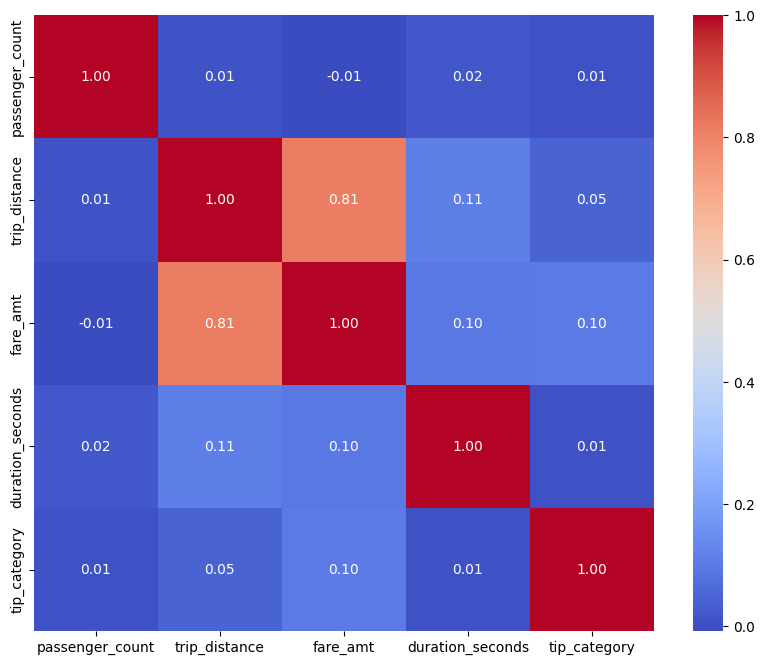

In [18]:
corr_df = data_jan_2009.select(pl.all().cast(pl.Float64)).to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

There will me multicolienarity between trip distance and fare amount. This result is understandable because there will be strong correlation between trip distance and fare amount. The longer of distance, the cost will be higher. But using tree type of classification, the impact of multicollinearity can be minimized.

## Step 8: Check the Balance of Target Dataset
This step is really important because imbalance target will give the classification method a chance to predicts the majority. This bias will suffer the minority but the accuracy will be remain high.  

In [19]:
data_jan_2009["tip_category"].value_counts()

tip_category,count
i32,u32
0,2932436
1,92216


There is an imbalance dataset. The solution is by balancing the dataset with SMOTE. It will be included in the data pipeline.

## Step 9: Select Features as Predictors and Target. Then Convert to Numpy.

In [20]:
y = data_jan_2009.select('tip_category').to_numpy().ravel().astype(int)
X = data_jan_2009.drop(['tip_category']).to_numpy()


## Step 10: Split Data into Train and Test

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

## Step 11: Create Data Pipeline with Logistic Regression

In [22]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

pipeline_lr = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

pipeline_lr.fit(X_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


## Step 12: Count the Accuracy

In [23]:
pipeline_lr.score(X_test,y_test)

0.7638219696802719

## Step 13: Create Data Pipeline with Random Forest Classifier

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
#from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

pipeline_rf = ImbPipeline(steps=[
    ('under', RandomUnderSampler(random_state=42)),
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Cross-validation to check performance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_rf, X_train, y_train, cv=cv, scoring='accuracy')
print("Cross-validation accuracy scores:", scores)
print("Mean CV accuracy:", scores.mean())

# Fit on training data
pipeline_rf.fit(X_train, y_train)

Cross-validation accuracy scores: [0.54913898 0.54698182 0.54801618 0.54763597 0.54897733]
Mean CV accuracy: 0.548150057910369


,steps,"[('under', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,replacement,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100


In [26]:
pipeline_rf.score(X_test,y_test)

0.5489080842322426

In [27]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

# ===== Example data (replace with your X and y) =====
#X = np.random.rand(10000, 10)     # Large dataset example
#y = np.random.choice([0,1], size=10000, p=[0.8, 0.2])  # imbalanced

# ===== CV setup =====
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ===== Scoring dictionary =====
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'roc_auc': make_scorer(roc_auc_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0)
}

# ===== Define different pipelines =====
pipelines = {
    'Baseline_RF': Pipeline([
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    
    'RF_class_weight': Pipeline([
        ('rf', RandomForestClassifier(n_estimators=100,
                                      class_weight='balanced',
                                      random_state=42))
    ]),
    
    'Partial_SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    
    'SMOTE_Tomek': ImbPipeline([
        ('resample', SMOTETomek(random_state=42, sampling_strategy=0.5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    
    'Borderline_SMOTE': ImbPipeline([
        ('smote', BorderlineSMOTE(random_state=42, sampling_strategy=0.5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

# ===== Run CV for each pipeline =====
results = {}

for name, pipe in pipelines.items():
    print(f"\nTraining {name}...")
    cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    # Store average scores
    results[name] = {metric: np.mean(scores) for metric, scores in cv_results.items() if metric.startswith('test_')}
    print(results[name])

# ===== Show final comparison =====
import pandas as pd
df_results = pd.DataFrame(results).T
print("\n=== Comparison of Methods ===")
print(df_results.sort_values(by='test_roc_auc', ascending=False))



Training Baseline_RF...
{'test_accuracy': np.float64(0.9648042155298151), 'test_roc_auc': np.float64(0.5119456432459537), 'test_precision': np.float64(0.9702226896088224), 'test_recall': np.float64(0.9942109563515287), 'test_f1': np.float64(0.9820703584887136)}

Training RF_class_weight...
{'test_accuracy': np.float64(0.8966469532991816), 'test_roc_auc': np.float64(0.5198947774107682), 'test_precision': np.float64(0.9707904091403166), 'test_recall': np.float64(0.9211116628909302), 'test_f1': np.float64(0.9452987409009728)}

Training Partial_SMOTE...
{'test_accuracy': np.float64(0.9406011006850866), 'test_roc_auc': np.float64(0.533325492082941), 'test_precision': np.float64(0.9715533836229913), 'test_recall': np.float64(0.9670478742516415), 'test_f1': np.float64(0.9692953551818135)}

Training SMOTE_Tomek...
{'test_accuracy': np.float64(0.9365817953139454), 'test_roc_auc': np.float64(0.5347764320648423), 'test_precision': np.float64(0.9716521707829591), 'test_recall': np.float64(0.96267


Best model by ROC AUC: SMOTE_Tomek


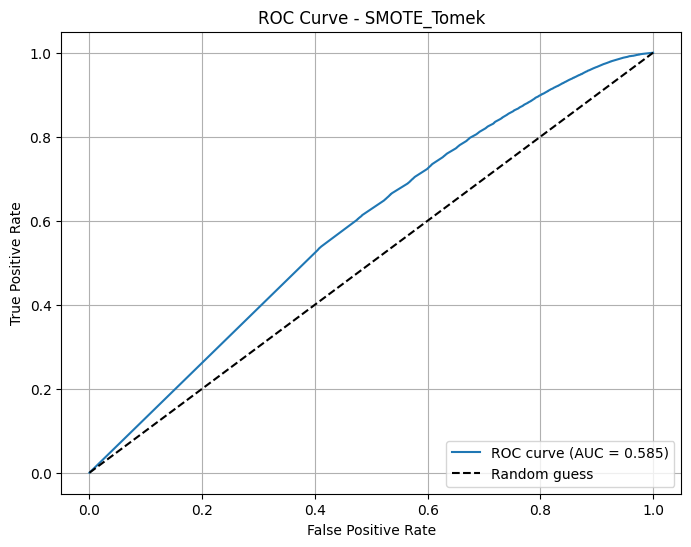

In [29]:
from sklearn.metrics import (make_scorer, accuracy_score, roc_auc_score,
                             f1_score, precision_score, recall_score,
                             roc_curve)
# ===== Pick best model by ROC AUC =====
best_model_name = df_results['test_roc_auc'].idxmax()
print(f"\nBest model by ROC AUC: {best_model_name}")

best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

# ===== ROC curve on hold-out test set =====
y_prob = best_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [22]:
# Use Light LBM. Change the target label first. 0 for majority and 1 for minority.
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, average_precision_score
import lightgbm as lgb

# Example X, y
# X = ...  # your feature matrix
# y = ...  # your labels (0 = majority, 1 = minority)

# Compute scale_pos_weight = (negatives / positives)
n_pos = np.sum(y == 1)
n_neg = np.sum(y == 0)
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# Define LightGBM classifier
lgbm = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=42
)

# Define PR AUC scorer (higher is better)
pr_auc_scorer = make_scorer(
    lambda y_true, y_prob: average_precision_score(y_true, y_prob),
    needs_proba=True
)

# Full pipeline: scaling + LightGBM
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),   # LightGBM can handle unscaled data, but scaling helps if mixing with other models
    ('clf', lgbm)
])

# Stratified CV for imbalanced data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation
scores = cross_validate(
    pipeline,
    X, y,
    cv=cv,
    scoring={
        'pr_auc': pr_auc_scorer,
        'roc_auc': 'roc_auc',
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    },
    return_train_score=False
)

# Print results
for metric in scores:
    if metric.startswith('test_'):
        print(f"{metric}: {scores[metric].mean():.4f} (+/- {scores[metric].std():.4f})")


scale_pos_weight = 31.80
[LightGBM] [Info] Number of positive: 73773, number of negative: 2345948
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 773
[LightGBM] [Info] Number of data points in the train set: 2419721, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, 

[LightGBM] [Info] Number of positive: 73772, number of negative: 2345949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 773
[LightGBM] [Info] Number of data points in the train set: 2419721, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459466
[LightGBM] [Info] Start training from score -3.459466


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, 

[LightGBM] [Info] Number of positive: 73773, number of negative: 2345949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 773
[LightGBM] [Info] Number of data points in the train set: 2419722, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, 

[LightGBM] [Info] Number of positive: 73773, number of negative: 2345949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013526 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 2419722, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, 

[LightGBM] [Info] Number of positive: 73773, number of negative: 2345949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 2419722, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


test_pr_auc: nan (+/- nan)
test_roc_auc: 0.6358 (+/- 0.0011)
test_accuracy: 0.7600 (+/- 0.0027)
test_precision: 0.0562 (+/- 0.0003)
test_recall: 0.4349 (+/- 0.0031)
test_f1: 0.0995 (+/- 0.0005)


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: <lambda>() got an unexpected keyword argument 'needs_proba'

  warnings.warn(


In [23]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, average_precision_score
import lightgbm as lgb

# Example X, y
# X = ...
# y = ...

# Compute scale_pos_weight = (negatives / positives)
n_pos = np.sum(y == 1)
n_neg = np.sum(y == 0)
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# LightGBM classifier
lgbm = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=42
)

# Use scikit-learn's built-in PR AUC scorer
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', lgbm)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipeline,
    X, y,
    cv=cv,
    scoring={
        'pr_auc': pr_auc_scorer,
        'roc_auc': 'roc_auc',
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    },
    return_train_score=False
)

for metric in scores:
    if metric.startswith('test_'):
        print(f"{metric}: {scores[metric].mean():.4f} (+/- {scores[metric].std():.4f})")


scale_pos_weight = 31.80
[LightGBM] [Info] Number of positive: 73773, number of negative: 2345948
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011539 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 773
[LightGBM] [Info] Number of data points in the train set: 2419721, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, 

[LightGBM] [Info] Number of positive: 73772, number of negative: 2345949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 773
[LightGBM] [Info] Number of data points in the train set: 2419721, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459466
[LightGBM] [Info] Start training from score -3.459466


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, 

[LightGBM] [Info] Number of positive: 73773, number of negative: 2345949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 773
[LightGBM] [Info] Number of data points in the train set: 2419722, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, 

[LightGBM] [Info] Number of positive: 73773, number of negative: 2345949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 2419722, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, 

[LightGBM] [Info] Number of positive: 73773, number of negative: 2345949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 2419722, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


test_pr_auc: nan (+/- nan)
test_roc_auc: 0.6358 (+/- 0.0011)
test_accuracy: 0.7600 (+/- 0.0027)
test_precision: 0.0562 (+/- 0.0003)
test_recall: 0.4349 (+/- 0.0031)
test_f1: 0.0995 (+/- 0.0005)


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\utils\_param_validation.py", line 196, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ekadw\anaconda3\envs\SQLite\Lib\inspect.py", line 3280, in bind
    return self._bind(args,

In [24]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, average_precision_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    stratify=y,
                                                    random_state=42)

# Handle class imbalance
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Build pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('clf', lgb.LGBMClassifier(objective='binary',
                               scale_pos_weight=pos_weight,
                               n_jobs=-1,
                               random_state=42))
])

# PR AUC scorer
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)

# Grid search
param_grid = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [-1, 10],
    'clf__learning_rate': [0.1, 0.05]
}

grid = GridSearchCV(pipeline,
                    param_grid,
                    cv=3,
                    scoring=pr_auc_scorer,
                    verbose=1,
                    n_jobs=-1)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best PR AUC:", grid.best_score_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\ekadw\anaconda3\envs\SQLite\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


[LightGBM] [Info] Number of positive: 73773, number of negative: 2345948
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 2419721, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030488 -> initscore=-3.459452
[LightGBM] [Info] Start training from score -3.459452
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': -1, 'clf__n_estimators': 100}
Best PR AUC: nan


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from sklearn.metrics import (make_scorer, accuracy_score, roc_auc_score,
                             f1_score, precision_score, recall_score,
                             roc_curve)

# ===== Example data (replace with your X and y) =====
#X = np.random.rand(10000, 10)     # Large dataset example
#y = np.random.choice([0,1], size=10000, p=[0.8, 0.2])  # imbalanced

# ===== Hold-out split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===== CV setup =====
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ===== Scoring dictionary =====
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'roc_auc': make_scorer(roc_auc_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0)
}

# ===== Define different pipelines =====
pipelines = {
    'Baseline_RF': Pipeline([
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    
    'RF_class_weight': Pipeline([
        ('rf', RandomForestClassifier(n_estimators=100,
                                      class_weight='balanced',
                                      random_state=42))
    ]),
    
    'Partial_SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    
    'SMOTE_Tomek': ImbPipeline([
        ('resample', SMOTETomek(random_state=42, sampling_strategy=0.5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    
    'Borderline_SMOTE': ImbPipeline([
        ('smote', BorderlineSMOTE(random_state=42, sampling_strategy=0.5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

# ===== Run CV for each pipeline =====
results = {}

for name, pipe in pipelines.items():
    print(f"\nTraining {name}...")
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: np.mean(scores)
                     for metric, scores in cv_results.items() if metric.startswith('test_')}
    print(results[name])

# ===== Show final comparison =====
df_results = pd.DataFrame(results).T
print("\n=== Comparison of Methods ===")
print(df_results.sort_values(by='test_roc_auc', ascending=False))

# ===== Pick best model by ROC AUC =====
best_model_name = df_results['test_roc_auc'].idxmax()
print(f"\nBest model by ROC AUC: {best_model_name}")

best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

# ===== ROC curve on hold-out test set =====
y_prob = best_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
pipeline = Pipeline([
    ('rf', RandomForestClassifier(n_estimators=100,
                                  class_weight='balanced',
                                  random_state=42))
])

Accuracy: 0.9931643093370179
Confusion Matrix:
 [[11063772    92059]
 [    4272  2932255]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00  11155831
           1       0.97      1.00      0.98   2936527

    accuracy                           0.99  14092358
   macro avg       0.98      1.00      0.99  14092358
weighted avg       0.99      0.99      0.99  14092358

ROC AUC: 0.9958318103698416


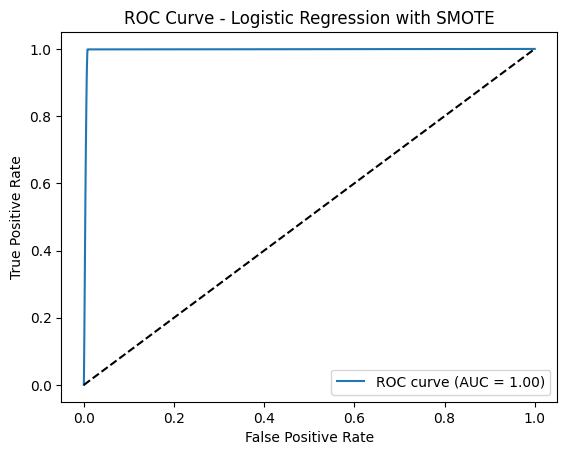

In [39]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# --- 1. Example data (replace with your own X, y)
#X, y = make_classification(
#    n_samples=2000, n_features=10, n_informative=5, n_redundant=2,
#    weights=[0.9, 0.1], random_state=42
#)

# --- 2. Build pipeline: SMOTE -> Scaling -> Logistic Regression
model = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))
])

# --- 3. Cross-validation (Stratified K-Fold preserves class balance)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use cross_val_predict to get out-of-fold predictions
y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

# --- 4. Metrics
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
roc_auc = roc_auc_score(y, y_proba)

print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y, y_pred))
print("ROC AUC:", roc_auc)

# --- 5. ROC curve plot
fpr, tpr, thresholds = roc_curve(y, y_proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression with SMOTE')
plt.legend()
plt.show()

CV Accuracy: 0.6648014712939265
Confusion Matrix (CV):
[[6521613 2403051]
 [1375939  973283]]
AUC (CV): 0.6110430074745824
Test Accuracy: 0.6652225035409257
Confusion Matrix (Test):
[[1631520  599647]
 [ 343914  243391]]
AUC (Test): 0.6117767017328857


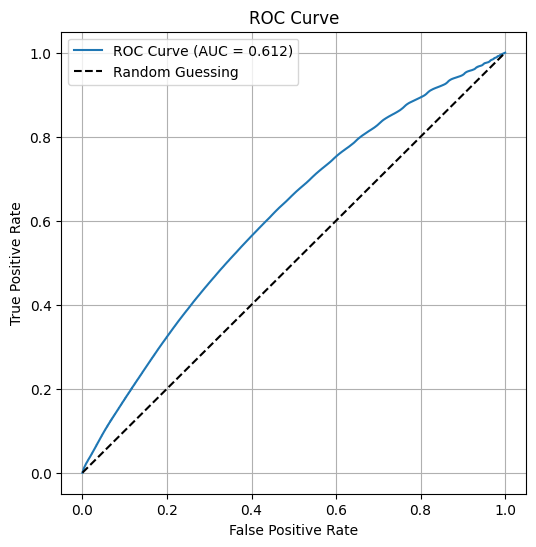

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# =======================
# 1. Prepare data
# =======================
# X: features (numpy array or pandas DataFrame)
# y: labels (numpy array or pandas Series)
# Example:
# X, y = ...
# Ensure y is numeric (0/1), not strings

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =======================
# 2. Define pipeline
# =======================
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=1000))
])

# =======================
# 3. Cross-validation (StratifiedKFold)
# =======================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict')
y_prob_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

print("CV Accuracy:", accuracy_score(y_train, y_pred_cv))
print("Confusion Matrix (CV):")
print(confusion_matrix(y_train, y_pred_cv))
print("AUC (CV):", roc_auc_score(y_train, y_prob_cv))

# =======================
# 4. Fit final model on full training set
# =======================
pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)
y_prob_test = pipeline.predict_proba(X_test)[:, 1]

# =======================
# 5. Evaluate on test set
# =======================
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))
print("AUC (Test):", roc_auc_score(y_test, y_prob_test))

# =======================
# 6. Plot ROC curve
# =======================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob_test):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import gc
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.base import clone
from joblib import parallel_backend

# ---- 1. Helper to force float32 (saves ~50% memory)
def to_float32(X):
    return np.asarray(X, dtype=np.float32)
float32_transformer = FunctionTransformer(to_float32, validate=False)

# ---- 2. Build the pipeline (SMOTE → scaling → RandomForest)
def build_pipeline():
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    scaler = StandardScaler(with_mean=True, with_std=True)
    rf = RandomForestClassifier(
        n_estimators=50,    # fewer trees → less memory
        max_depth=12,       # limit depth
        max_samples=0.6,    # subsample each tree
        n_jobs=1,           # single-thread to avoid memory blowup during CV
        random_state=42,
        verbose=0
    )

    pipe = Pipeline([
        ('to_float32', float32_transformer),  # downcast first
        ('smote', smote),
        ('scaler', scaler),
        ('clf', rf)
    ])
    return pipe

# ---- 3. Manual CV with ROC evaluation (works with DataFrame or ndarray)
def cv_roc_oof(X, y, pipeline, n_splits=3, random_state=42, plot_roc=True):
    X = np.asarray(X)  # ensure ndarray indexing works
    y = np.asarray(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_probs = np.zeros(len(y), dtype=np.float32)

    fold = 0
    with parallel_backend('threading'):
        for train_idx, test_idx in skf.split(X, y):
            fold += 1
            print(f"[CV] Fold {fold}/{n_splits} — train {len(train_idx)}, test {len(test_idx)}")

            X_train, X_test = X[train_idx], X[test_idx]
            y_train = y[train_idx]

            est = clone(pipeline)
            est.fit(X_train, y_train)   # SMOTE happens here only on train fold

            probs = est.predict_proba(X_test)[:, 1].astype(np.float32)
            oof_probs[test_idx] = probs

            del est, X_train, X_test, y_train, probs
            gc.collect()

    roc_auc = roc_auc_score(y, oof_probs)
    fpr, tpr, thresholds = roc_curve(y, oof_probs, pos_label=1)
    print(f"[CV] Out-of-fold ROC AUC: {roc_auc:.4f}")

    if plot_roc:
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f'OOF ROC (AUC = {roc_auc:.4f})')
        plt.plot([0,1],[0,1],'--', alpha=0.5)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Out-of-Fold ROC')
        plt.legend()
        plt.grid(True)
        plt.show()

    return oof_probs, roc_auc, (fpr, tpr, thresholds)

# ---- 4. Run it (X and y must already be ready)
pipeline = build_pipeline()
oof_probs, auc_val, roc_data = cv_roc_oof(X, y, pipeline, n_splits=3)


[CV] Fold 1/3 — train 9394905, test 4697453


In [30]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np

# Example dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2,
                           weights=[0.9, 0.1], random_state=42)

# Split into train/test before applying SMOTE (apply only on train!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Original dataset shape:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Resampled dataset shape:", dict(zip(*np.unique(y_resampled, return_counts=True))))


Original dataset shape: {np.int64(0): np.int64(628), np.int64(1): np.int64(72)}
Resampled dataset shape: {np.int64(0): np.int64(628), np.int64(1): np.int64(628)}
